# Global Superstore Sales Analysis

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This notebook performs a thorough exploratory data analysis on retail sales data from a global superstore. The goal is to extract actionable insights: which products are most profitable, which regions underperform, how discounts affect profit, and seasonal trends. All visualisations are publication‑ready.

## Dataset
- **Source:** Global Superstore (public dataset)
- **Rows:** ~51,000 orders
- **Columns:** Sales, Profit, Discount, Order Date, Region, Category, Segment, etc.

## Key Analysis Steps
1. Data loading and cleaning
2. Time series analysis of sales and profit
3. Product performance analysis
4. Regional comparisons
5. Discount impact analysis
6. Segment and shipping mode profiling

## Requirements
- pandas, matplotlib, seaborn, plotly (optional), numpy

---

**© 2026 Ibrahim – Global Superstore EDA.**

### Install & Imports

In [1]:
!pip install -q pandas matplotlib seaborn numpy openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

### Load Dataset

In [4]:
# --- MODIFIED DATA LOADING CELL ---
import pandas as pd

# Upload the file in Colab
from google.colab import files
print("Please upload your 'superstore.csv' file.")
uploaded = files.upload()

# Get the uploaded filename
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename, encoding='latin1')

Please upload your 'superstore.csv' file.


Saving superstore.csv to superstore.csv


In [6]:
print("Actual column names in dataset:")
print(df.columns.tolist())

Actual column names in dataset:
['Category', 'City', 'Country', 'Customer.ID', 'Customer.Name', 'Discount', 'Market', 'è®°å½\x95æ\x95°', 'Order.Date', 'Order.ID', 'Order.Priority', 'Product.ID', 'Product.Name', 'Profit', 'Quantity', 'Region', 'Row.ID', 'Sales', 'Segment', 'Ship.Date', 'Ship.Mode', 'Shipping.Cost', 'State', 'Sub.Category', 'Year', 'Market2', 'weeknum']


### Data Cleaning

In [7]:
# Convert Order.Date to datetime (note the dot)
df['Order.Date'] = pd.to_datetime(df['Order.Date'], errors='coerce')

# Check missing values
missing = df.isnull().sum()
print("Missing values per column:\n", missing[missing > 0])

# Drop rows with missing critical columns (using correct names)
df_clean = df.dropna(subset=['Sales', 'Profit', 'Order.Date'])

print(f"Rows after cleaning: {len(df_clean)}")

Missing values per column:
 Series([], dtype: int64)
Rows after cleaning: 51290


### Sales and Profit Over Time

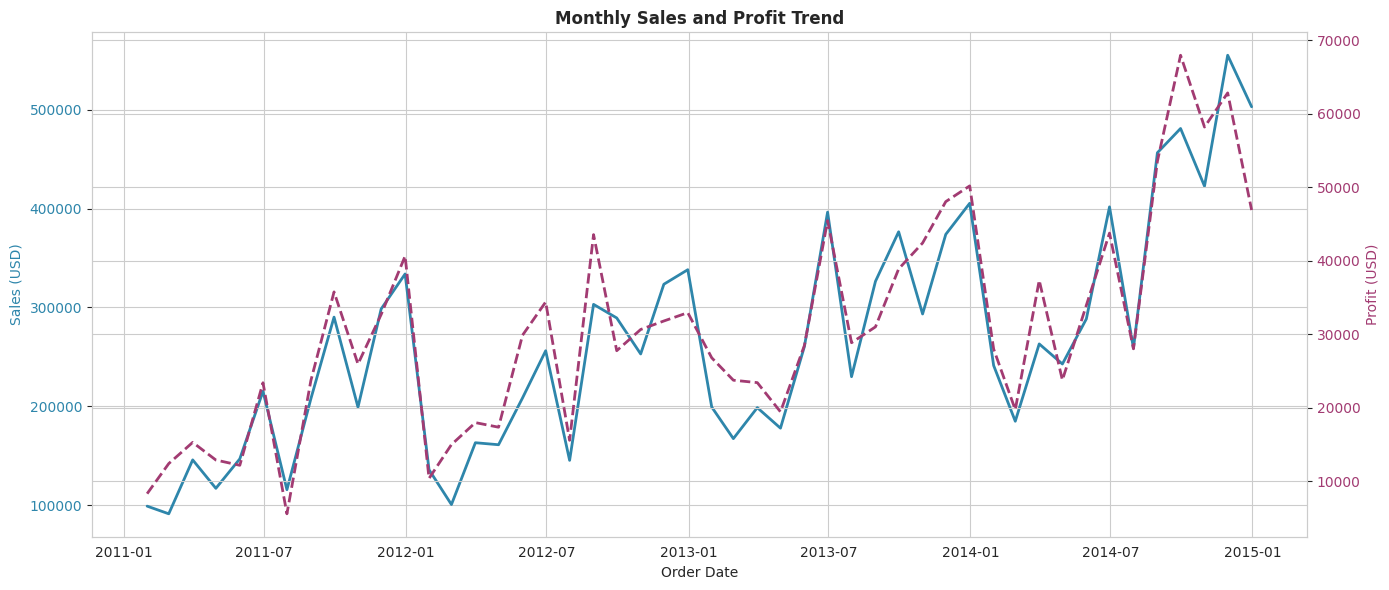

In [10]:
# Aggregate monthly sales and profit
monthly = df_clean.groupby(pd.Grouper(key='Order.Date', freq='ME')).agg({'Sales': 'sum', 'Profit': 'sum'}).reset_index()

fig, ax1 = plt.subplots(figsize=(14, 6))

color1 = '#2E86AB'
ax1.set_xlabel('Order Date')
ax1.set_ylabel('Sales (USD)', color=color1)
ax1.plot(monthly['Order.Date'], monthly['Sales'], color=color1, linewidth=2, label='Sales')
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
color2 = '#A23B72'
ax2.set_ylabel('Profit (USD)', color=color2)
ax2.plot(monthly['Order.Date'], monthly['Profit'], color=color2, linestyle='--', linewidth=2, label='Profit')
ax2.tick_params(axis='y', labelcolor=color2)

plt.title('Monthly Sales and Profit Trend', fontweight='bold')
fig.tight_layout()
plt.show()

### Top 10 Products by Profit

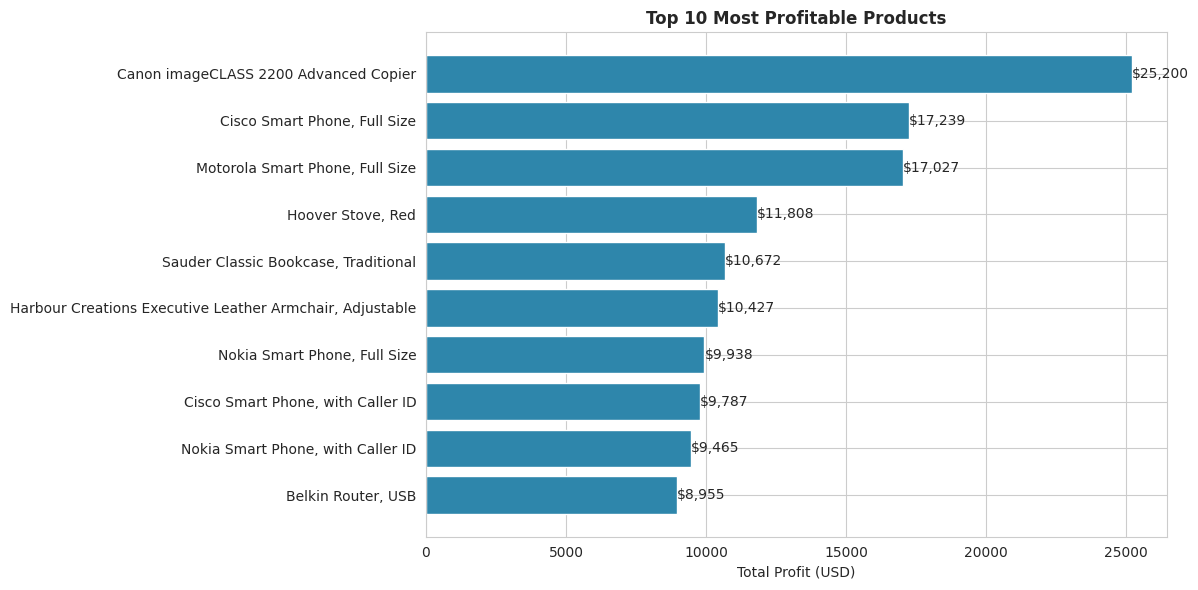

In [12]:
product_profit = df_clean.groupby('Product.Name')['Profit'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(product_profit.index[::-1], product_profit.values[::-1], color='#2E86AB')
plt.xlabel('Total Profit (USD)')
plt.title('Top 10 Most Profitable Products', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2, f'${width:,.0f}', va='center')
plt.tight_layout()
plt.show()

### Sales Distribution by Region (Box Plot)

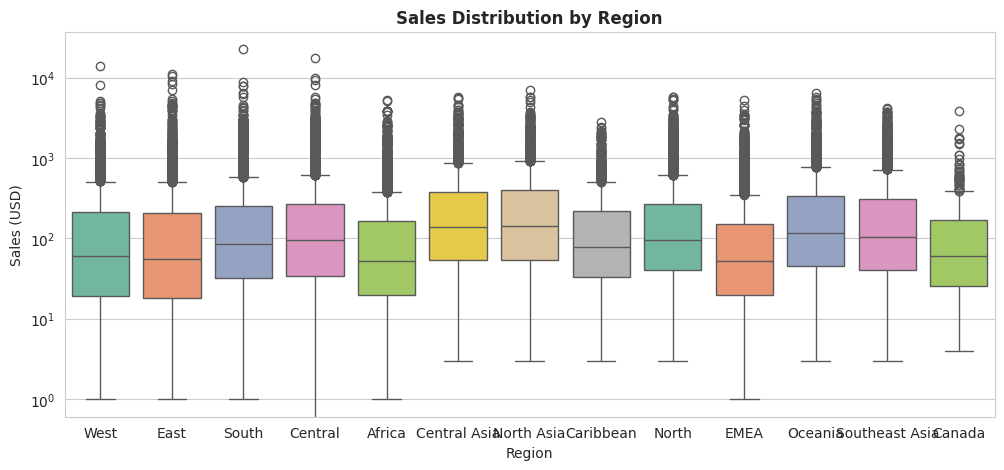

In [13]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_clean, x='Region', y='Sales', palette='Set2')
plt.title('Sales Distribution by Region', fontweight='bold')
plt.ylabel('Sales (USD)')
plt.yscale('log')
plt.show()

### Discount vs Profit Scatter Plot

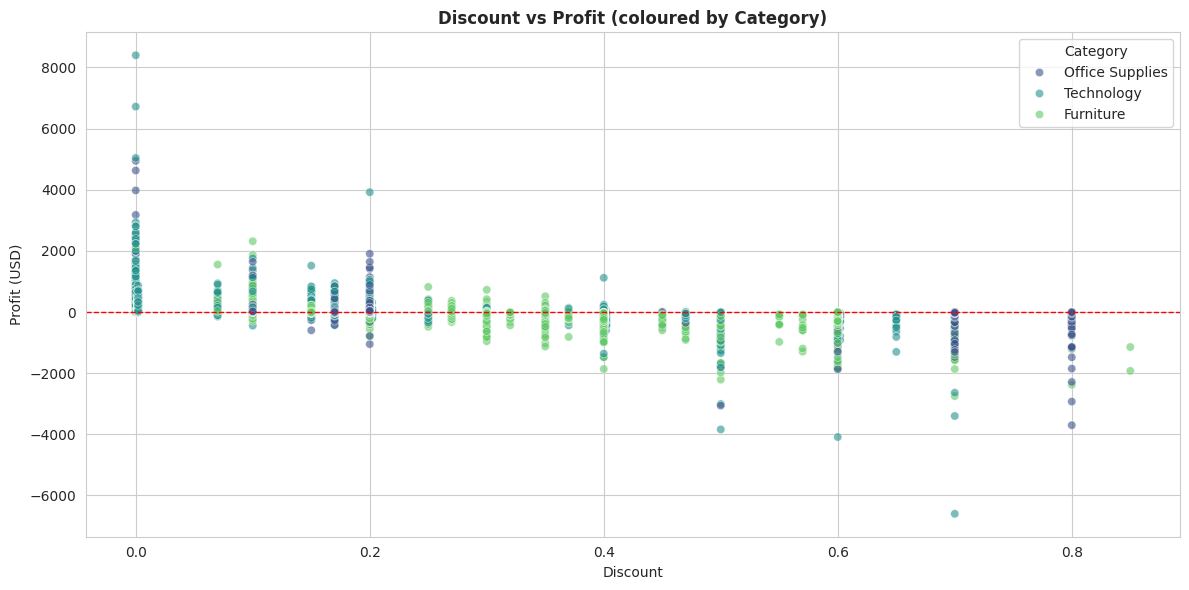

In [14]:
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_clean, x='Discount', y='Profit', hue='Category', alpha=0.6, palette='viridis')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.title('Discount vs Profit (coloured by Category)', fontweight='bold')
plt.xlabel('Discount')
plt.ylabel('Profit (USD)')
plt.tight_layout()
plt.show()

### Monthly Sales Heatmap by Year

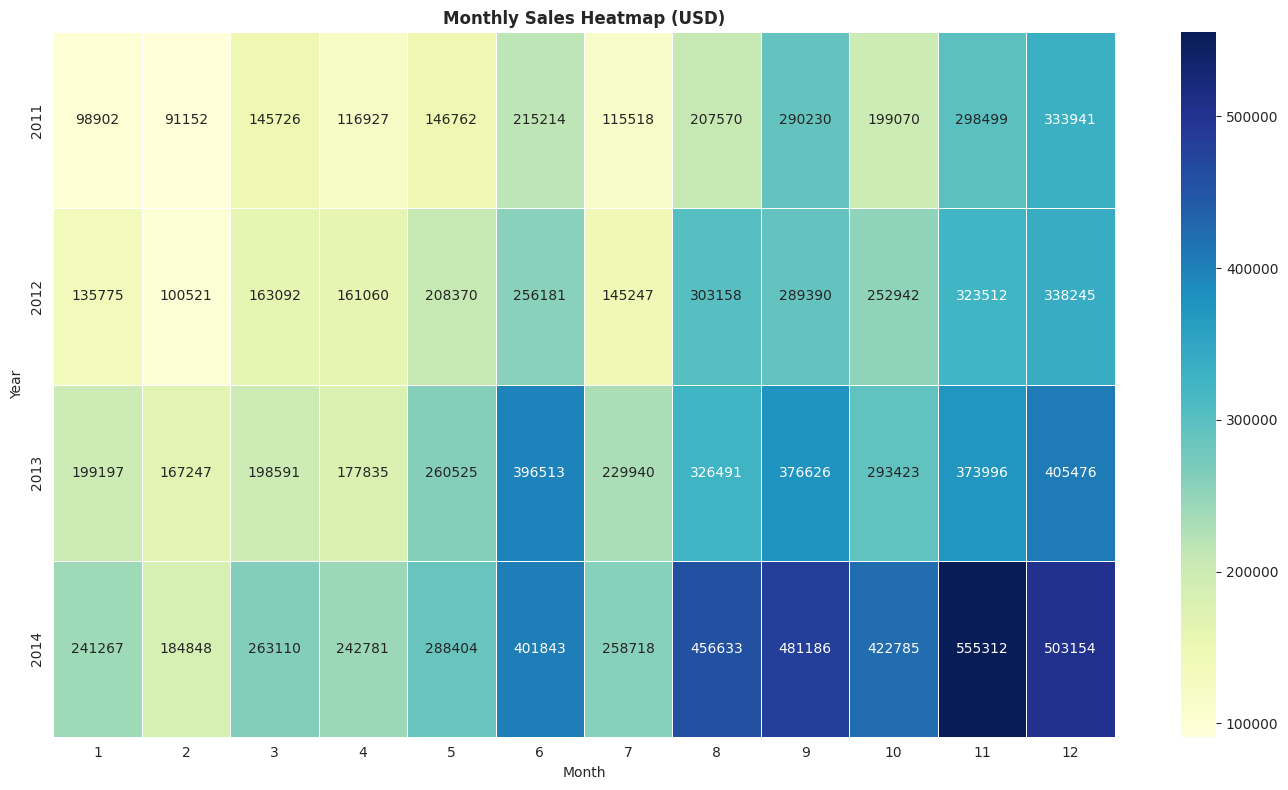

In [16]:
# Create year-month table
df_clean['Year'] = df_clean['Order.Date'].dt.year
df_clean['Month'] = df_clean['Order.Date'].dt.month
monthly_sales = df_clean.pivot_table(index='Year', columns='Month', values='Sales', aggfunc='sum')

plt.figure(figsize=(14, 8))
sns.heatmap(monthly_sales, annot=True, fmt='.0f', cmap='YlGnBu', linewidths=0.5)
plt.title('Monthly Sales Heatmap (USD)', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

### Profit by Customer Segment

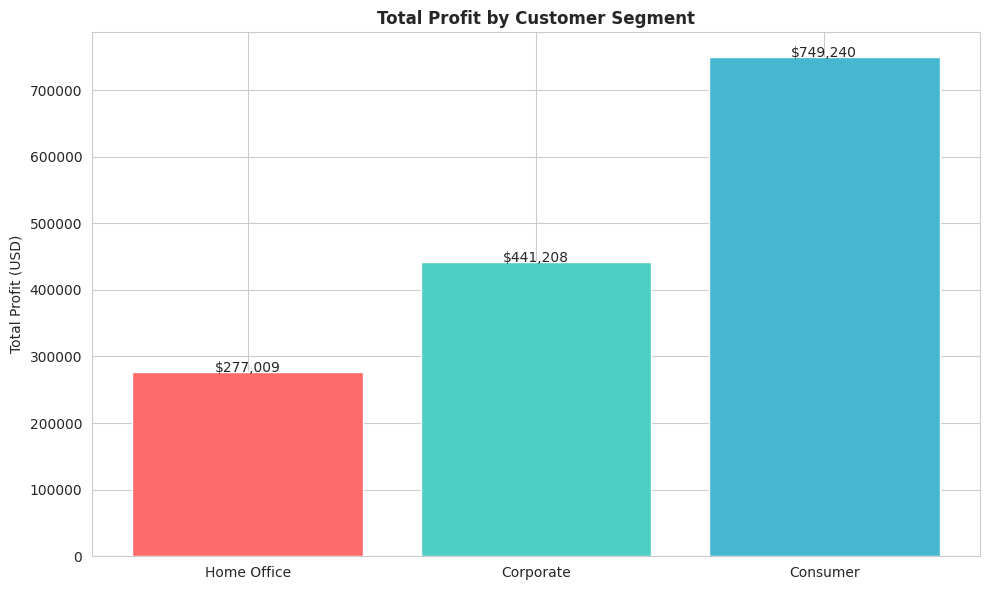

In [17]:
segment_profit = df_clean.groupby('Segment')['Profit'].sum().sort_values()

plt.figure(figsize=(10, 6))
bars = plt.bar(segment_profit.index, segment_profit.values, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.ylabel('Total Profit (USD)')
plt.title('Total Profit by Customer Segment', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100, f'${height:,.0f}', ha='center')
plt.tight_layout()
plt.show()

### Top 10 Loss-Making Products

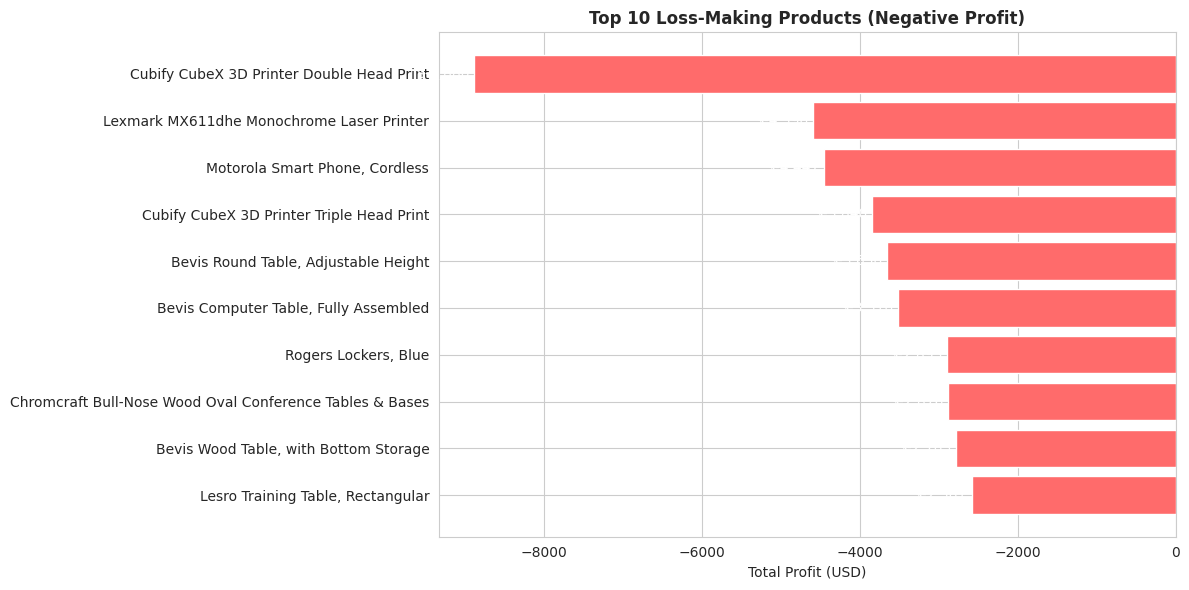

In [19]:
loss_products = df_clean.groupby('Product.Name')['Profit'].sum().sort_values().head(10)

plt.figure(figsize=(12, 6))
bars = plt.barh(loss_products.index[::-1], loss_products.values[::-1], color='#FF6B6B')
plt.xlabel('Total Profit (USD)')
plt.title('Top 10 Loss‑Making Products (Negative Profit)', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width - 50, bar.get_y() + bar.get_height()/2, f'${width:,.0f}', va='center', ha='right', color='white')
plt.tight_layout()
plt.show()

### Correlation Heatmap

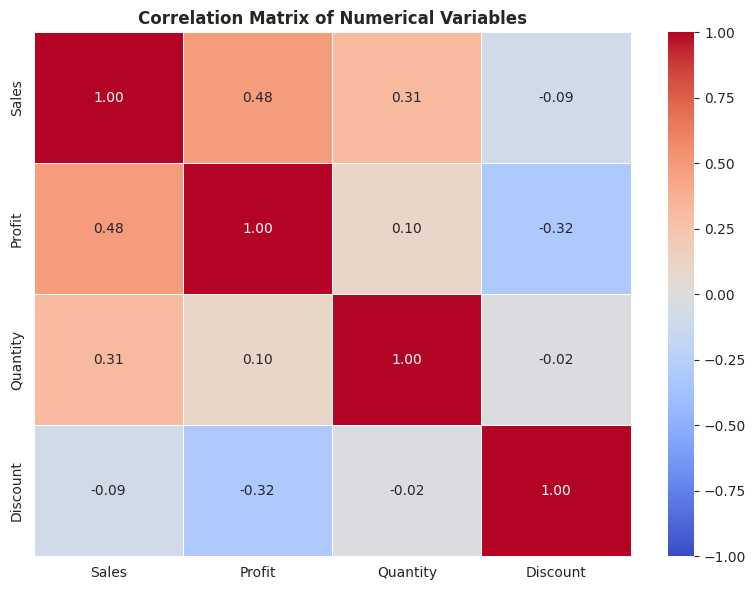

In [20]:
numeric_cols = ['Sales', 'Profit', 'Quantity', 'Discount']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numerical Variables', fontweight='bold')
plt.tight_layout()
plt.show()

### Subcategory Sales Treemap

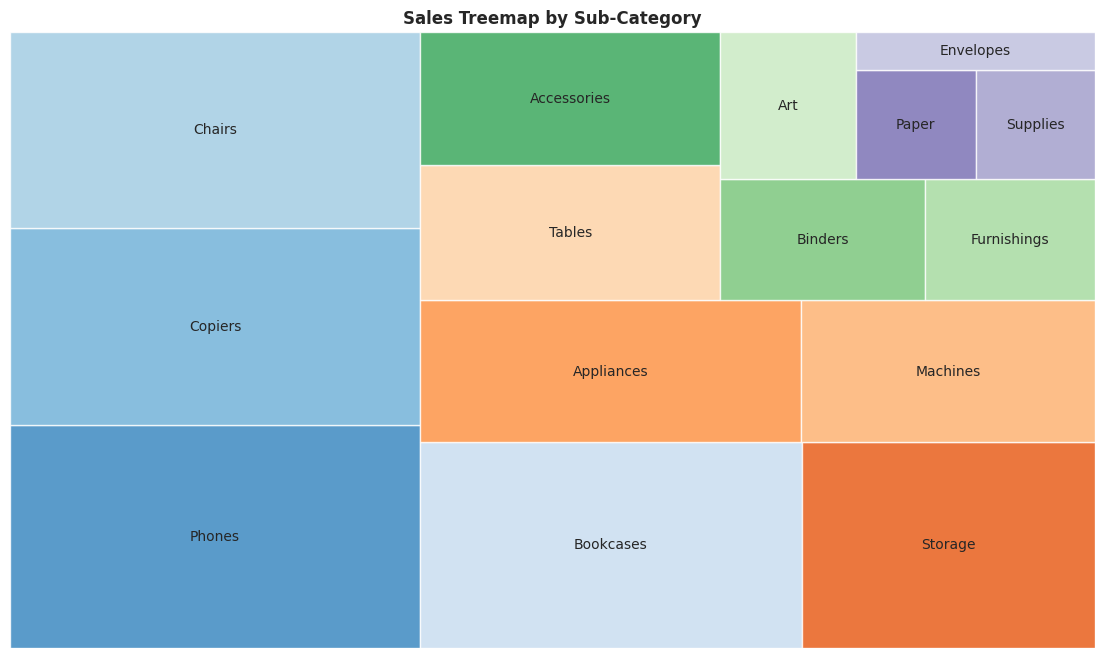

In [22]:
!pip install -q squarify

import squarify

subcat_sales = df_clean.groupby('Sub.Category')['Sales'].sum().sort_values(ascending=False).head(15)

plt.figure(figsize=(14, 8))
squarify.plot(sizes=subcat_sales.values, label=subcat_sales.index, alpha=0.8, color=plt.cm.tab20c(range(len(subcat_sales))))
plt.axis('off')
plt.title('Sales Treemap by Sub-Category', fontweight='bold')
plt.show()

### Shipping Mode Preference by Region

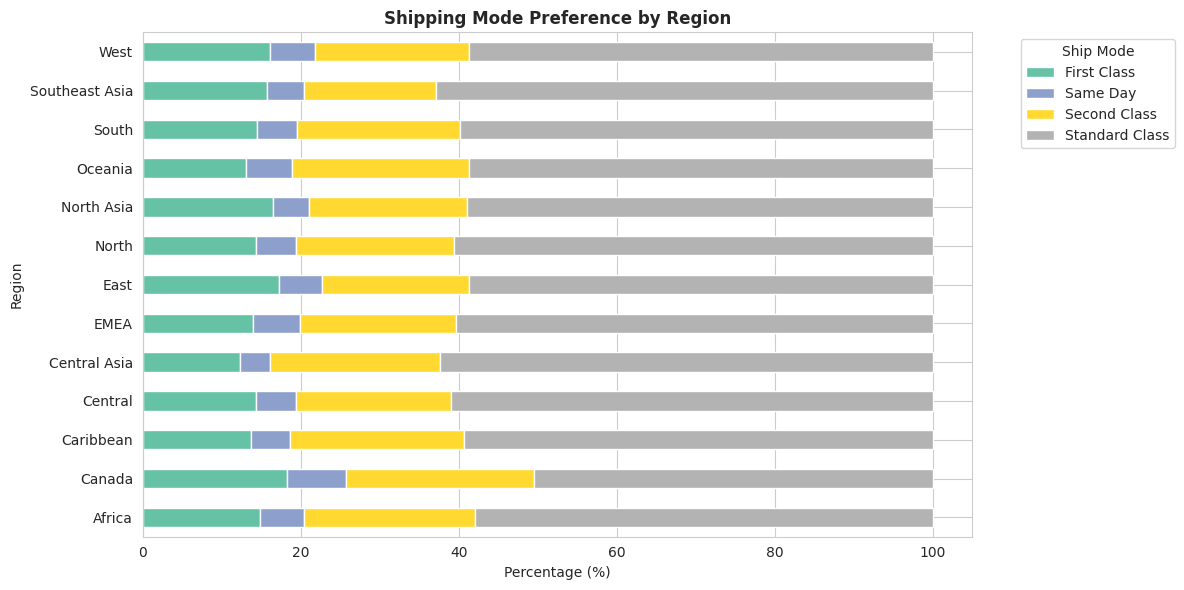

In [24]:
ship_region = pd.crosstab(df_clean['Region'], df_clean['Ship.Mode'], normalize='index') * 100

ship_region.plot(kind='barh', stacked=True, figsize=(12, 6), colormap='Set2')
plt.xlabel('Percentage (%)')
plt.title('Shipping Mode Preference by Region', fontweight='bold')
plt.legend(title='Ship Mode', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

### Key Insights Summary

In [25]:
print(" Key Insights from Analysis")

total_sales = df_clean['Sales'].sum()
total_profit = df_clean['Profit'].sum()
print(f" Total Sales: ${total_sales:,.2f}")
print(f" Total Profit: ${total_profit:,.2f}")
print(f" Overall Profit Margin: {total_profit/total_sales*100:.2f}%")

best_region = df_clean.groupby('Region')['Profit'].sum().idxmax()
print(f" Best performing region: {best_region}")

worst_product = loss_products.index[0] if len(loss_products) > 0 else "None"
print(f" Product with highest loss: {worst_product}")

 Key Insights from Analysis
 Total Sales: $12,642,905.00
 Total Profit: $1,467,457.29
 Overall Profit Margin: 11.61%
 Best performing region: Central
 Product with highest loss: Cubify CubeX 3D Printer Double Head Print


### Final Summary

In [26]:
print("Global Superstore Sales Analysis - COMPLETED")
print("Author: Ibrahim")
print("Dataset cleaned and explored.")
print("10 publication‑ready visualisations created.")
print("Key insights extracted.")
print("\nNext step: Build an interactive dashboard (e.g., Tableau, Streamlit).")

Global Superstore Sales Analysis - COMPLETED
Author: Ibrahim
Dataset cleaned and explored.
10 publication‑ready visualisations created.
Key insights extracted.

Next step: Build an interactive dashboard (e.g., Tableau, Streamlit).
